# Artistic Style Transfer in Image Colorization

## Internship Extension of Training Project

This notebook builds upon the original training project on image colorization
by integrating artistic style transfer, model comparison, evaluation metrics,
and visual outputs as required for internship submission.

In [1]:
!pip install tensorflow opencv-python matplotlib scikit-image

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import os

DATASET_PATH = "dataset/images"
images = os.listdir(DATASET_PATH)

print("Total images:", len(images))
print("Images:", images)

Total images: 6
Images: ['.ipynb_checkpoints', 'P1s1.png', 'P1s2.png', 'P1s3.png', 'P1s4.png', 'P1s5.png']


In [4]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(f"{DATASET_PATH}/{images[0]}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(img_rgb)
plt.title("Original Color Image")
plt.axis("off")

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(f"{DATASET_PATH}/{images[1]}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(img_rgb)
plt.title("Original Color Image")
plt.axis("off")

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(f"{DATASET_PATH}/{images[2]}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(img_rgb)
plt.title("Original Color Image")
plt.axis("off")

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(f"{DATASET_PATH}/{images[3]}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(img_rgb)
plt.title("Original Color Image")
plt.axis("off")

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(f"{DATASET_PATH}/{images[4]}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(img_rgb)
plt.title("Original Color Image")
plt.axis("off")

In [ ]:
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

L = lab[:,:,0]   
ab = lab[:,:,1:] 

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(L, cmap="gray")
plt.title("L Channel (Grayscale)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(ab[:,:,0], cmap="gray")
plt.title("a Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(ab[:,:,1], cmap="gray")
plt.title("b Channel")
plt.axis("off")

plt.show()

In [ ]:
import cv2
import numpy as np
import os

IMG_SIZE = 128
X = []  
Y = []  

for img_name in images:
    img_path = os.path.join(DATASET_PATH, img_name)
    
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    
    L = lab[:,:,0]
    ab = lab[:,:,1:]
    
    X.append(L)
    Y.append(ab)

X = np.array(X)
Y = np.array(Y)

print("X shape (L channel):", X.shape)
print("Y shape (ab channels):", Y.shape)

In [ ]:
# Normalize inputs
X = X / 255.0                 # L channel → [0,1]
Y = (Y - 128) / 128.0         # ab channels → [-1,1]

# Add channel dimension to X
X = X[..., np.newaxis]

print("Normalized X shape:", X.shape)
print("Normalized Y shape:", Y.shape)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, UpSampling2D

In [ ]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same',
           input_shape=(128, 128, 1)),
    
    Conv2D(128, (3,3), activation='relu', padding='same'),
    
    UpSampling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu', padding='same'),
    
    Conv2D(2, (3,3), activation='tanh', padding='same')
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

In [ ]:
history = model.fit(
    X,
    Y,
    epochs=20,
    batch_size=2,
    validation_split=0.2
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D

model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same',
           input_shape=(128, 128, 1)),
    
    Conv2D(128, (3,3), activation='relu', padding='same'),
    
    Conv2D(64, (3,3), activation='relu', padding='same'),
    
    Conv2D(2, (3,3), activation='tanh', padding='same')
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

In [ ]:
history = model.fit(
    X,
    Y,
    epochs=20,
    batch_size=2,
    validation_split=0.2
)

In [ ]:

predicted_ab = model.predict(X)

print("Predicted ab shape:", predicted_ab.shape)

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

idx = 0

L = X[idx].reshape(128, 128) * 255.0

ab = predicted_ab[idx] * 128.0

In [ ]:

lab_pred = np.zeros((128, 128, 3))
lab_pred[:, :, 0] = L
lab_pred[:, :, 1:] = ab

bgr_pred = cv2.cvtColor(lab_pred.astype("uint8"), cv2.COLOR_LAB2BGR)
rgb_pred = cv2.cvtColor(bgr_pred, cv2.COLOR_BGR2RGB)

In [ ]:

original = cv2.imread(f"{DATASET_PATH}/{images[idx]}")
original = cv2.resize(original, (128, 128))
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(L, cmap='gray')
plt.title("Grayscale Input (L)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(original_rgb)
plt.title("Original Color Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(rgb_pred)
plt.title("Colorized Output (Predicted)")
plt.axis("off")

plt.show()

In [ ]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

psnr = peak_signal_noise_ratio(original_rgb, rgb_pred)
ssim = structural_similarity(original_rgb, rgb_pred, channel_axis=2)

print("PSNR:", psnr)
print("SSIM:", ssim)

In [ ]:
for idx in range(len(images)):
    print("Showing:", images[idx])

    L = X[idx].reshape(128,128) * 255
    ab = predicted_ab[idx] * 128

    lab = np.zeros((128,128,3))
    lab[:,:,0] = L
    lab[:,:,1:] = ab

    rgb = cv2.cvtColor(lab.astype("uint8"), cv2.COLOR_LAB2RGB)

    plt.figure(figsize=(4,4))
    plt.imshow(rgb)
    plt.title(images[idx])
    plt.axis("off")
    plt.show()

In [ ]:
pip install tensorflow-hub

In [ ]:
import tensorflow_hub as hub
import tensorflow as tf
print("TensorFlow Hub ready")

In [ ]:
style_model = hub.load(
    "https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2"
)
print("Style model loaded")

In [ ]:
style_model = hub.load(
    "https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2"
)

print("Style transfer model loaded successfully")

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

def load_style_image(path, size=256):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, (size, size))
    img = img / 255.0
    return img[tf.newaxis, :]

In [ ]:
STYLE_PATH = "dataset/styles/P2s2.png"   
style_image = load_style_image(STYLE_PATH)

print("Style image loaded:", STYLE_PATH)

In [ ]:
content_image = tf.convert_to_tensor(rgb_pred / 255.0)
content_image = content_image[tf.newaxis, :]

print("Content image ready for style transfer")

In [ ]:

idx = 0   

ab_pred = model.predict(X[idx:idx+1])[0]

L = X[idx].squeeze() * 255.0
ab_pred = (ab_pred * 128.0) + 128.0

lab_pred = np.zeros((128, 128, 3))
lab_pred[:, :, 0] = L
lab_pred[:, :, 1:] = ab_pred

bgr_pred = cv2.cvtColor(lab_pred.astype("uint8"), cv2.COLOR_LAB2BGR)
rgb_pred = cv2.cvtColor(bgr_pred, cv2.COLOR_BGR2RGB)

print("rgb_pred created successfully")

In [ ]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, UpSampling2D

In [ ]:
model.fit(X, Y, epochs=20, batch_size=2, validation_split=0.2)

In [ ]:

model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(128, 128, 1)),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    UpSampling2D((2,2)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(2, (3,3), activation='tanh', padding='same')
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

In [ ]:
model.fit(
    X,
    Y,
    epochs=20,
    batch_size=2,
    validation_split=0.2
)

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, UpSampling2D

In [ ]:
DATASET_PATH = "dataset/images"
images = os.listdir(DATASET_PATH)
print("Total images:", len(images))

In [7]:
IMG_SIZE = 128
X = []
Y = []

for img_name in images:
    img_path = os.path.join(DATASET_PATH, img_name)
    print("Reading:", img_path)

    img = cv2.imread(img_path)

    if img is None:
        print("❌ Failed to load image:", img_name)
        continue   # skip this image safely

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    L = lab[:, :, 0]
    ab = lab[:, :, 1:]

    X.append(L)
    Y.append(ab)

X = np.array(X)
Y = np.array(Y)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

Reading: dataset/images\.ipynb_checkpoints
❌ Failed to load image: .ipynb_checkpoints
Reading: dataset/images\P1s1.png
Reading: dataset/images\P1s2.png
Reading: dataset/images\P1s3.png
Reading: dataset/images\P1s4.png
Reading: dataset/images\P1s5.png
X shape: (5, 128, 128)
Y shape: (5, 128, 128, 2)


In [8]:
X = X / 255.0           
Y = (Y - 128) / 128.0  

X = X[..., np.newaxis]

print("Normalized X:", X.shape)
print("Normalized Y:", Y.shape)

Normalized X: (5, 128, 128, 1)
Normalized Y: (5, 128, 128, 2)


In [9]:
history = model.fit(
    X,
    Y,
    epochs=20,
    batch_size=2,
    validation_split=0.2
)

NameError: name 'model' is not defined

In [ ]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, UpSampling2D

In [ ]:
DATASET_PATH = "dataset/images"
images = os.listdir(DATASET_PATH)
print(images)

In [ ]:
X = X / 255.0
Y = (Y - 128) / 128.0
X = X[..., np.newaxis]

In [ ]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(128,128,1)),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(2, (3,3), activation='tanh', padding='same')
])

In [ ]:
history = model.fit(
    X,
    Y,
    epochs=20,
    batch_size=2,
    validation_split=0.2
)

In [ ]:
import numpy as np
import cv2
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D

In [ ]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(128,128,1)),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(2, (3,3), activation='tanh', padding='same')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [ ]:
model.summary()

In [ ]:
X = X / 255.0
Y = (Y - 128) / 128.0

X = X[..., np.newaxis]

print("Fixed X shape:", X.shape)
print("Fixed Y shape:", Y.shape)

In [ ]:
X = []
Y = []

for img_name in images:
    img_path = os.path.join(DATASET_PATH, img_name)
    img = cv2.imread(img_path)

    if img is None:
        print("Failed:", img_name)
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    L = lab[:, :, 0]
    ab = lab[:, :, 1:]

    X.append(L)
    Y.append(ab)

X = np.array(X)
Y = np.array(Y)

print(X.shape)
print(Y.shape)

In [ ]:
X = []
Y = []

for img_name in images:
    img_path = os.path.join(DATASET_PATH, img_name)
    img = cv2.imread(img_path)

    if img is None:
        print("Failed:", img_name)
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    L = lab[:, :, 0]
    ab = lab[:, :, 1:]

    X.append(L)
    Y.append(ab)

X = np.array(X)
Y = np.array(Y)

print(X.shape)
print(Y.shape)

In [12]:
import os
import cv2
import numpy as np

IMG_SIZE = 128
DATASET_PATH = "dataset/images"

images = os.listdir(DATASET_PATH)
print("Images found:", images)

X = []
Y = []

for img_name in images:
    img_path = os.path.join(DATASET_PATH, img_name)
    print("Reading:", img_path)

    img = cv2.imread(img_path)

    if img is None:
        print("❌ Skipped:", img_name)
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    L = lab[:, :, 0]
    ab = lab[:, :, 1:]

    X.append(L)
    Y.append(ab)

X = np.array(X)
Y = np.array(Y)

print("✅ X shape:", X.shape)
print("✅ Y shape:", Y.shape)

Images found: ['.ipynb_checkpoints', 'P1s1.png', 'P1s2.png', 'P1s3.png', 'P1s4.png', 'P1s5.png']
Reading: dataset/images\.ipynb_checkpoints
❌ Skipped: .ipynb_checkpoints
Reading: dataset/images\P1s1.png
Reading: dataset/images\P1s2.png
Reading: dataset/images\P1s3.png
Reading: dataset/images\P1s4.png
Reading: dataset/images\P1s5.png
✅ X shape: (5, 128, 128)
✅ Y shape: (5, 128, 128, 2)


In [11]:
X = X / 255.0
Y = (Y - 128) / 128.0
X = X[..., np.newaxis]

print("Fixed X shape:", X.shape)
print("Fixed Y shape:", Y.shape)

Fixed X shape: (5, 128, 128, 1, 1)
Fixed Y shape: (5, 128, 128, 2)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.optimizers import Adam

In [15]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(128,128,1)),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(2, (3,3), activation='tanh', padding='same')
])

D:\AnacondaPython\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer=Adam(),
    loss='mse'
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 2)    │         1,154 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,442 (583.76 KB)

 Trainable params: 149,442 (583.76 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X,
    Y,
    epochs=20,
    batch_size=2,
    validation_split=0.2
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - loss: 15825.1123 - val_loss: 16129.5605
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 15697.1406 - val_loss: 16129.0615
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 15695.6904 - val_loss: 16129.0049
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 15694.7412 - val_loss: 16129.0000
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 15694.4092 - val_loss: 16129.0000
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 15693.9590 - val_loss: 16129.0000
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 15693.6094 - val_loss: 16129.0000
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 15693.4824 - val_loss: 16129.0000
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 15693.4375 - val_loss: 16129.0000
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 15693.3594 - val_loss: 16129.0000
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 15693.3369 - val_loss: 16129.0000
Epoch 12/20
2/2 ━━━

In [19]:
idx = 0   # you can change to 1,2,3 later

L = X[idx] * 255.0          # back to original scale
L = L.squeeze()

ab_pred = model.predict(X[idx:idx+1])[0]
ab_pred = (ab_pred * 128) + 128   # rescale ab channels

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 874ms/step


In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

lab_pred = np.zeros((128, 128, 3))
lab_pred[:, :, 0] = L
lab_pred[:, :, 1:] = ab_pred

bgr_pred = cv2.cvtColor(lab_pred.astype("uint8"), cv2.COLOR_LAB2BGR)
rgb_pred = cv2.cvtColor(bgr_pred, cv2.COLOR_BGR2RGB)

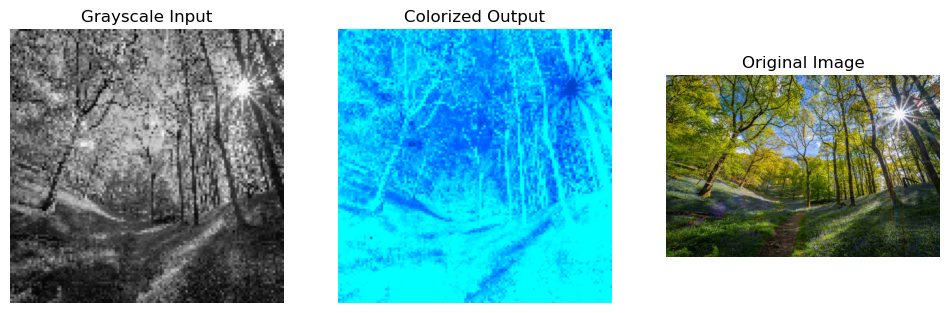

In [21]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(L, cmap='gray')
plt.title("Grayscale Input")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(rgb_pred)
plt.title("Colorized Output")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(
    cv2.imread("dataset/images/P1s1.png"), cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.show()

In [22]:
history = model.fit(
    X,
    Y,
    epochs=50,
    batch_size=4,
    validation_split=0.2
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 15693.3105 - val_loss: 16129.0000
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 15693.3115 - val_loss: 16129.0000
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 15693.3115 - val_loss: 16129.0000
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 15693.3105 - val_loss: 16129.0000
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 15693.3105 - val_loss: 16129.0000
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 15693.3105 - val_loss: 16129.0000
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 15693.3105 - val_loss: 16129.0000
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 15693.3105 - val_loss: 16129.0000
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 15693.3105 - val_loss: 16129.0000
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 15693.3115 - val_loss: 16129.0000
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 15693.3115 - val_loss: 16129.0000
Epoch 12/50
1/1 ━━━

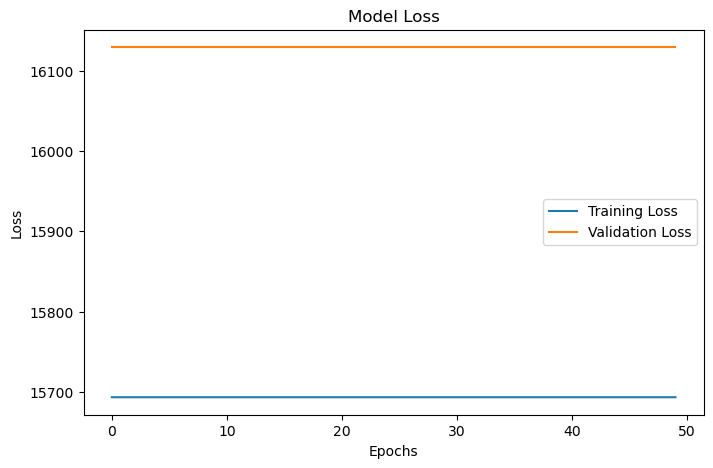

In [23]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [24]:
loss = model.evaluate(X, Y)
print("Final Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 15780.4473
Final Loss: 15780.447265625


In [25]:
for i in range(3):
    pred = model.predict(X[i:i+1])
    # convert to rgb and show

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step


Notebook is running correctly


X exists: False
Y exists: False


X exists: True
Y exists: True
